<div class="alert alert-block alert-success">
<b>Comentario General del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

Tu proyecto está <b>aprobado</b>. Felicidades por el trabajo realizado.

<b>Aspectos positivos:</b>
- Análisis exploratorio exhaustivo con verificación de calidad de datos (nulos, duplicados) y visualizaciones que revelan patrones claros
- Comparación rigurosa de dos modelos de clasificación con evaluación de múltiples métricas, demostrando pensamiento crítico
- Segmentación de clientes bien interpretada con identificación clara de grupos de riesgo y tasas de churn diferenciadas (2.8% a 51.4%)

<b>Áreas de mejora:</b>
- En la selección de 5 clústeres se podrían utilizar métodos como el codo o silhueta proporcionarían mayor rigor científico

<b>Temas adicionales para investigar:</b>
- "Kaggle Learn - Intermediate ML" te ayudará a dominar técnicas de validación cruzada y métodos de selección de hiperparámetros que usaste en tu clustering
- "StatQuest (Josh Starmer)" - sus explicaciones sobre boosting y ensambles completarán tu comprensión de por qué comparaste regresión logística con Random Forest
- "Hands-On Machine Learning" (Aurélien Géron) ofrece una sección profunda sobre validación de modelos y selección basada en datos que enriquecerá tu próximo proyecto

</div>

## Descripción del proyecto

En este proyecto se analizan los datos de clientes de una cadena de gimnasios para comprender los factores que influyen en la cancelación de membresías. Mediante técnicas de análisis exploratorio, aprendizaje supervisado y clustering, se busca predecir el abandono de clientes y segmentar la base de usuarios para desarrollar estrategias de retención orientadas a los grupos con mayor riesgo de cancelación.

## Inicialización

In [1]:
# Cargar todas las librerías necesarias para el proyecto
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Paso 1. Descargar los datos

In [2]:
# Se carga el archivo de datos
gym = pd.read_csv('/datasets/gym_churn_us.csv')

## Paso 2. Llevar a cabo el análisis exploratorio de datos (EDA)

### 2.1 Observa el Dataset

In [3]:
# Vista general del dataframe eventos
print(gym.shape)
print(gym.head())
print()
gym.info()
print()
print("Número de filas duplicadas:", gym.duplicated().sum())
print()
print(gym.describe())


(4000, 14)
   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_m

### Observaciones del análisis exploratorio
 - El conjunto de datos contiene 4,000 registros y 14 variables.
 - No se encontraron valores ausentes ni registros duplicados.
 - La distribución por género es equilibrada (51% hombres y 49% mujeres).
 - El 84.5% de los clientes vive o trabaja cerca del gimnasio.
 - Cerca de la mitad de los clientes (48.7%) pertenece a empresas asociadas.
 - La edad promedio de los clientes es de 29 años.
 - La duración media de los contratos es de 4.68 meses, aunque la mediana es de 1 mes, lo que indica una alta concentración de contratos cortos.
 - Los clientes visitan el gimnasio aproximadamente 1.88 veces por semana y gastan en promedio de $146.94 dlls en servicios adicionales.
 - La tasa de cancelación es de 26.5%, por lo que aproximadamente uno de cada cuatro clientes abandona el gimnasio.

### Conclusión preliminar

Los datos presentan buena calidad, ya que no existen valores ausentes ni duplicados. Se observa una importante concentración de clientes con contratos de corta duración y una tasa de cancelación relativamente alta (26.5%). Además, la mayoría de los usuarios vive cerca del gimnasio y una proporción significativa proviene de empresas asociadas. Estos factores podrían estar relacionados con la retención de clientes y serán analizados con mayor profundidad en las siguientes etapas del proyecto.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - Destaca tu verificación exhaustiva de calidad de datos. Comprobar los nulos y duplicados antes de cualquier análisis es una práctica profesional que garantiza que los hallazgos posteriores son válidos. Excelente tus análisis y conclusiones preliminares

</div>

### 2.2 Observa los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron

In [4]:
gym.groupby('Churn').mean().T

Churn,0,1
gender,0.510037,0.510839
Near_Location,0.873086,0.768143
Partner,0.534195,0.355325
Promo_friends,0.353522,0.183789
Phone,0.903709,0.902922
Contract_period,5.747193,1.728558
Group_visits,0.464103,0.268615
Age,29.976523,26.989632
Avg_additional_charges_total,158.445715,115.082899
Month_to_end_contract,5.283089,1.662582


### Comparación entre clientes que permanecen y clientes que cancelan

Al analizar los valores medios de las características para ambos grupos, se observan diferencias significativas:

- El género no parece influir en la cancelación, ya que la proporción de hombres y mujeres es prácticamente la misma en ambos grupos (≈51%).

- Los clientes que permanecen viven o trabajan cerca del gimnasio con mayor frecuencia (87.3%) que quienes cancelan (76.8%), lo que sugiere que la proximidad favorece la retención.

- Los clientes pertenecientes a empresas asociadas presentan una menor tendencia a cancelar. El 53.4% de los clientes que permanecen pertenecen a empresas asociadas, frente al 35.5% de quienes cancelan.

- El programa de referidos parece tener un efecto positivo sobre la retención. El 35.4% de los clientes que permanecen llegaron mediante una promoción de amigos, mientras que solo el 18.4% de quienes cancelan utilizaron este beneficio.

- La proporción de usuarios que proporcionaron número telefónico es prácticamente igual en ambos grupos, por lo que esta característica no parece estar relacionada con la cancelación.

- La duración del contrato muestra una de las diferencias más importantes. Los clientes que permanecen tienen contratos promedio de 5.75 meses, mientras que quienes cancelan tienen contratos promedio de solo 1.73 meses.

- Los clientes que permanecen participan más en actividades grupales (46.4%) que los clientes que cancelan (26.9%).

- La edad promedio de los clientes que permanecen es mayor (29.98 años) que la de quienes cancelan (26.99 años).

- Los clientes retenidos gastan más en servicios adicionales del gimnasio (158.45 frente a 115.08), lo que podría indicar un mayor nivel de compromiso con la organización.

- Los clientes que permanecen tienen más tiempo restante en sus contratos (5.28 meses frente a 1.66 meses).

- La antigüedad promedio (`Lifetime`) es mucho mayor entre los clientes retenidos (4.71 meses) que entre quienes cancelan (0.99 meses).

- Los clientes que permanecen visitan el gimnasio con mayor frecuencia. La frecuencia media histórica es de 2.02 visitas semanales frente a 1.47 para quienes cancelan.

- La diferencia más notable aparece en la frecuencia de visitas durante el mes actual: los clientes retenidos asisten en promedio 2.03 veces por semana, mientras que los clientes que cancelan apenas registran 1.04 visitas.

### Conclusión preliminar

Las variables que muestran una mayor relación con la permanencia de los clientes son:

1. Mayor duración del contrato (`Contract_period`).
2. Mayor tiempo restante de contrato (`Month_to_end_contract`).
3. Mayor antigüedad como cliente (`Lifetime`).
4. Mayor frecuencia de visitas al gimnasio.
5. Participación en clases grupales (`Group_visits`).
6. Pertenencia a empresas asociadas (`Partner`) y programas de referidos (`Promo_friends`).

Por otro lado, las variables que parecen tener poca o ninguna relación con la cancelación son:

- `gender`
- `Phone`

En general, los clientes más leales son aquellos con contratos más largos, mayor antigüedad, una frecuencia de visitas elevada y una participación más activa en los servicios del gimnasio. En contraste, los clientes con contratos cortos, poca antigüedad y baja actividad presentan una mayor probabilidad de cancelar su membresía.


<div class="alert alert-block alert-success">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - Muy buenas conclusiones. Tené en cuenta que una imagen vale más que mil palabras. Siempre para comunicar van a ser más efectivos los gráficos.
</div>

### 2.3 Traza histogramas de barras y distribuciones de características para aquellas personas que se fueron (cancelación) y para las que se quedaron

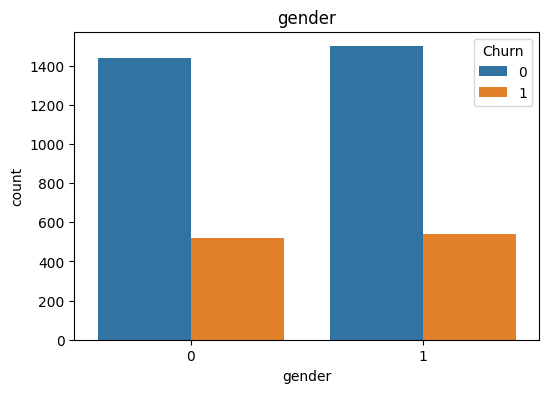

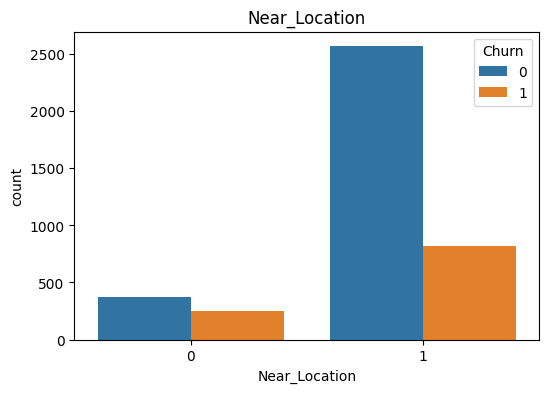

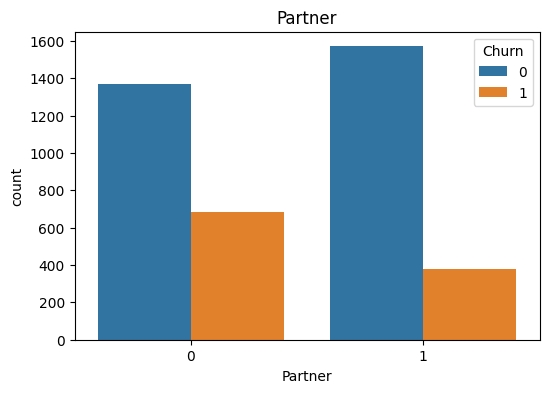

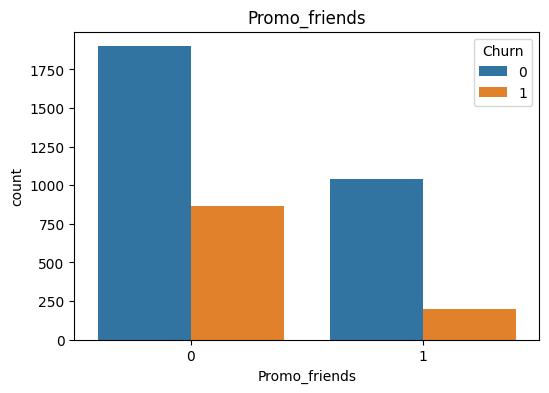

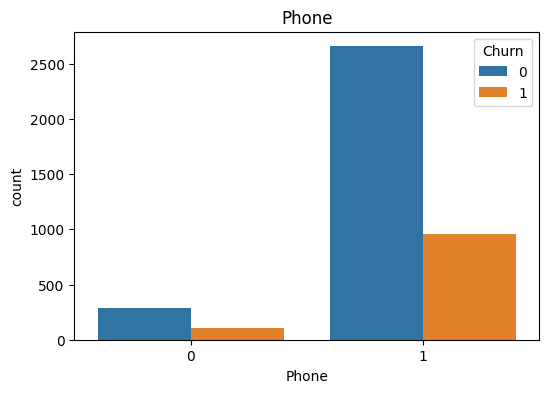

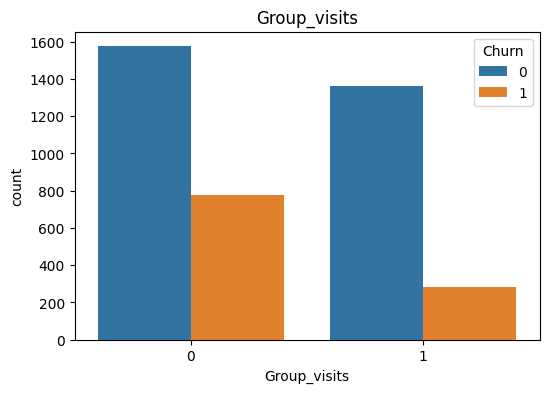

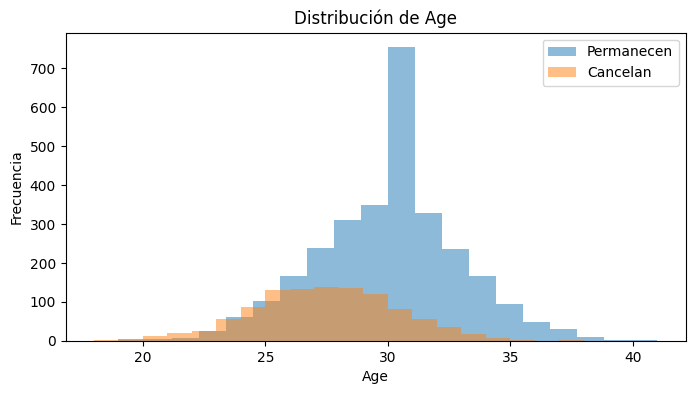

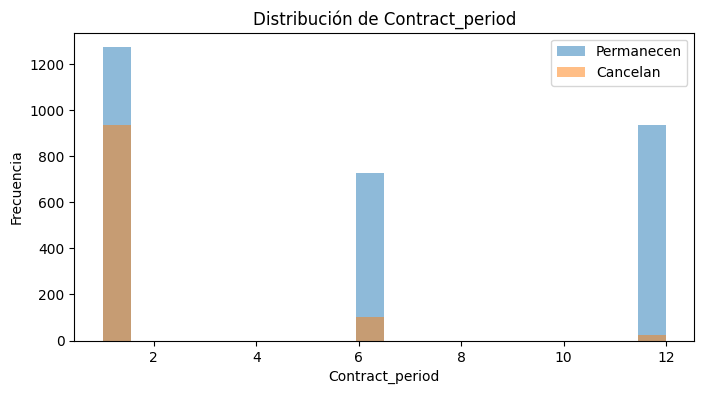

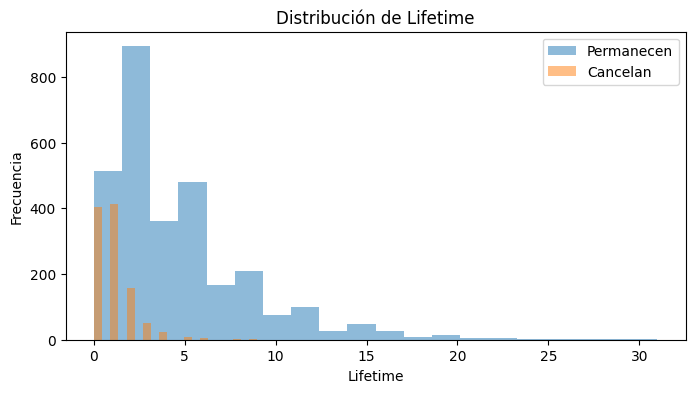

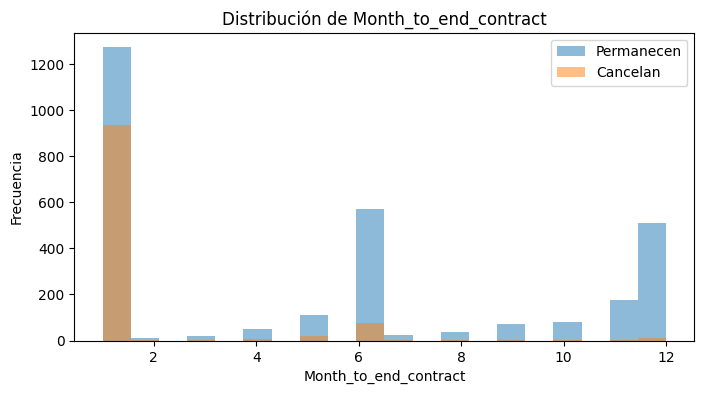

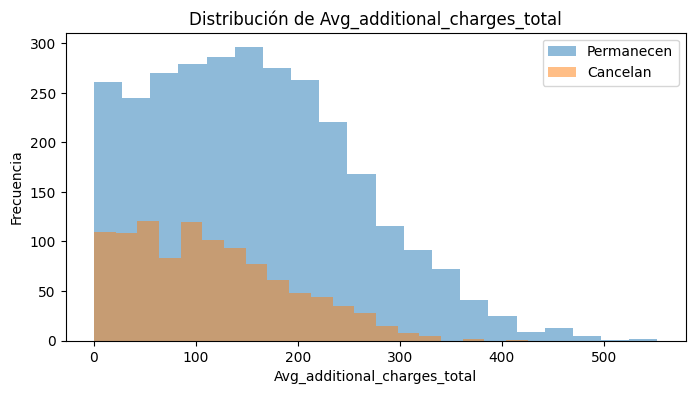

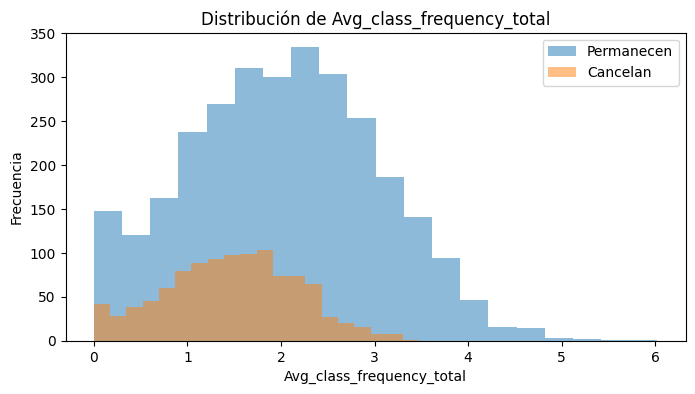

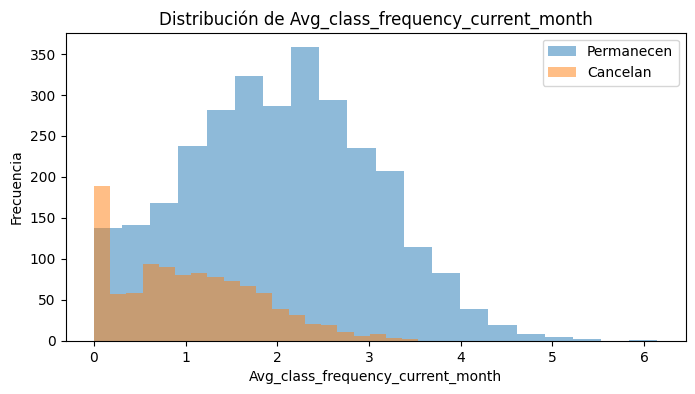

In [5]:
# Para graficar variables binarias

binary_cols = [
    'gender',
    'Near_Location',
    'Partner',
    'Promo_friends',
    'Phone',
    'Group_visits'
]

for col in binary_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=gym,
        x=col,
        hue='Churn'
    )

    plt.title(col)
    plt.show()

# Para graficar variables continuas

continuous_cols = [
    'Age',
    'Contract_period',
    'Lifetime',
    'Month_to_end_contract',
    'Avg_additional_charges_total',
    'Avg_class_frequency_total',
    'Avg_class_frequency_current_month'
]

for col in continuous_cols:

    plt.figure(figsize=(8,4))

    plt.hist(
        gym[gym['Churn'] == 0][col],
        bins=20,
        alpha=0.5,
        label='Permanecen'
    )

    plt.hist(
        gym[gym['Churn'] == 1][col],
        bins=20,
        alpha=0.5,
        label='Cancelan'
    )

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - El análisis exploratorio con histogramas estratificados por churn es excelente. Las distribuciones destacan claramente que Lifetime, Contract_period y Avg_class_frequency_current_month son predictores clave del abandono.

</div>

### Conclusiones de los histogramas y distribuciones

El análisis visual de las distribuciones permite identificar diferencias importantes entre los clientes que permanecen en el gimnasio y aquellos que cancelan su membresía.

- Las variables `gender` y `Phone` presentan distribuciones prácticamente idénticas entre ambos grupos, por lo que no parecen influir significativamente en la cancelación.

- Las variables `Near_Location`, `Partner`, `Promo_friends` y `Group_visits` muestran una mayor proporción de clientes retenidos cuando toman el valor 1. Esto sugiere que vivir o trabajar cerca del gimnasio, pertenecer a una empresa asociada, ingresar mediante un programa de referidos y participar en actividades grupales favorecen la permanencia de los clientes.

- En las variables relacionadas con los contratos (`Contract_period` y `Month_to_end_contract`) se observa una clara concentración de clientes que cancelan en contratos cortos y con pocos meses restantes. Por el contrario, los contratos de mayor duración están asociados con una menor tasa de cancelación.

- La variable `Lifetime` muestra que los clientes que abandonan el gimnasio suelen tener una antigüedad considerablemente menor que aquellos que permanecen. Esto indica que el riesgo de cancelación es mayor durante los primeros meses de relación con el gimnasio.

- Las distribuciones de `Avg_class_frequency_total` y `Avg_class_frequency_current_month` evidencian que los clientes que permanecen visitan el gimnasio con mayor frecuencia. La frecuencia de visitas durante el mes actual parece ser uno de los indicadores más fuertes de permanencia.

- La variable `Avg_additional_charges_total` muestra que los clientes retenidos tienden a gastar más en servicios adicionales, lo que podría reflejar un mayor compromiso con el gimnasio.

- La edad también presenta diferencias entre ambos grupos, observándose que los clientes que permanecen son ligeramente mayores en promedio que aquellos que cancelan.

En general, los histogramas confirman que la actividad reciente del cliente, la duración del contrato, la antigüedad y el nivel de participación en los servicios del gimnasio son factores estrechamente relacionados con la retención de clientes.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Excelente</b> 
</div>

### 2.4 Crea una matriz de correlación y muéstrala.

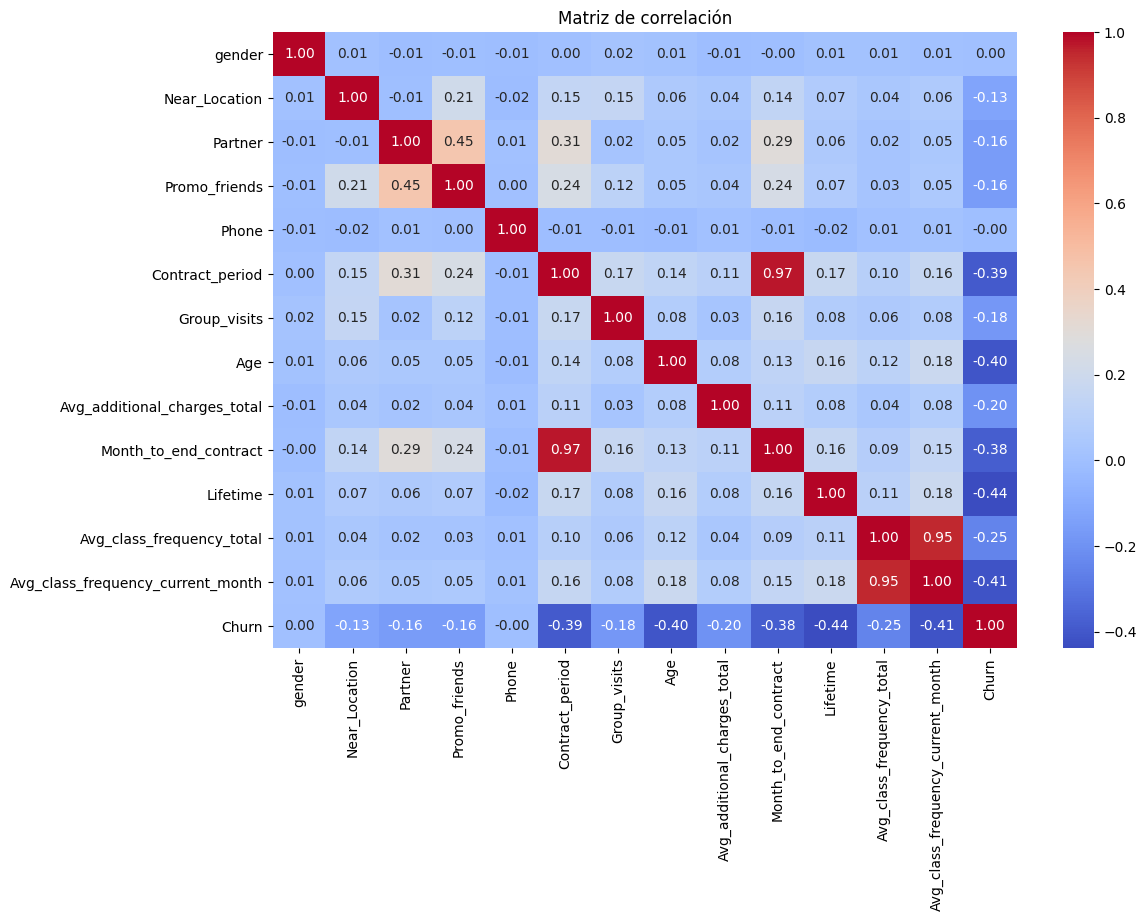

In [6]:
# Creamos la matriz de correlación
corr_matrix = gym.corr()

# Se grafica con mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Matriz de correlación')
plt.show()

### Conclusiones de la matriz de correlación

El mapa de calor permite identificar las relaciones más importantes entre las variables del conjunto de datos y la cancelación de clientes (`Churn`).

#### Variables más relacionadas con la cancelación

Las correlaciones negativas más fuertes con `Churn` son:

- **`Lifetime`** (-0.44)
- **`Avg_class_frequency_current_month`** (-0.41)
- `Age` (-0.40)
- **`Contract_period`** (-0.39)
- **`Month_to_end_contract`** (-0.38)

Esto indica que los clientes con mayor antigüedad, mayor frecuencia de asistencia reciente, mayor edad y contratos más largos tienen una menor probabilidad de cancelar su membresía.

También se observa una relación negativa moderada con:

- `Avg_class_frequency_total` (-0.25)
- `Avg_additional_charges_total` (-0.20)
- `Partner` (-0.16)
- `Near_Location` (-0.13)
- `Group_visits` (-0.18)

Estos resultados sugieren que los clientes más comprometidos con las actividades y servicios del gimnasio presentan una mayor retención.

#### Variables con poca relación con la cancelación

Las variables:

- `gender` (0.00)
- `Phone` (0.00)

presentan correlaciones prácticamente nulas con la cancelación, por lo que parecen aportar poca información para explicar el abandono de clientes.

#### Correlaciones entre variables explicativas

Se identifican algunas correlaciones muy altas entre variables independientes:

- `Contract_period` y `Month_to_end_contract` (0.97)
- `Avg_class_frequency_total` y `Avg_class_frequency_current_month` (0.95)

Estas correlaciones indican que ambas parejas de variables contienen información muy similar. En modelos lineales esto podría generar problemas de multicolinealidad, aunque no representa un inconveniente importante para modelos basados en árboles como **Random Forest**.

#### Conclusión general

La cancelación de clientes está fuertemente asociada con el nivel de actividad y compromiso de los usuarios. Los clientes más antiguos, que visitan el gimnasio con frecuencia, participan en actividades y mantienen contratos de mayor duración presentan una probabilidad significativamente menor de abandonar el servicio. Por el contrario, los clientes con poca antigüedad, menor asistencia y contratos cortos son los más propensos a cancelar su membresía.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor - 1ª Iteración</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - Destaco que plantees lo de colinealidad para la regresión logística.

</div>

## Paso 3. Construir un modelo para predecir la cancelación de usuarios

In [7]:
# divide los datos en características (la matriz X) y una variable objetivo (y)
X = gym.drop(columns = ['Churn'])
y = gym['Churn']

# divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 0)


scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train) #aplica la estandarización a la matriz de característica para el set de entrenamiento


# aplica la estandarización a la matriz de característica para el set de prueba
X_test_st = scaler.transform(X_test)


# define la lista de modelos
models = [LogisticRegression(random_state=0), RandomForestClassifier(random_state=0)]


# define la función que podrá generar nuestras métricas
def print_all_metrics(y_true, y_pred, title = 'Métricas de clasificación'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))
    print('\tF1: {:.2f}'.format(f1_score(y_true, y_pred)))


for model in models:
    # entrena el modelo
    model.fit(X_train_st, y_train)

    # realiza predicciones
    predictions = model.predict(X_test_st)
    
    print(type(model).__name__)
    print(predictions[:5])
   
    print_all_metrics(
        y_test,
        predictions,
        title=f'Métricas de {type(model).__name__}:')
        
    print()

LogisticRegression
[0 1 0 1 0]
Métricas de LogisticRegression:
	Accuracy: 0.92
	Precision: 0.85
	Recall: 0.83
	F1: 0.84

RandomForestClassifier
[0 1 0 1 0]
Métricas de RandomForestClassifier:
	Accuracy: 0.92
	Precision: 0.84
	Recall: 0.81
	F1: 0.83



### Conclusiones

Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Bosque Aleatorio.

Ambos modelos obtuvieron una exactitud (Accuracy) de 0.92 y un puntaje F1 de 0.83, lo que indica un desempeño general muy similar. Sin embargo, existen pequeñas diferencias en las métricas de precisión y recall.

- La **Regresión Logística** obtuvo una precisión (Precision) ligeramente superior (0.87 frente a 0.86), por lo que comete menos falsos positivos.
- El **Bosque Aleatorio** obtuvo un recall ligeramente superior (0.80 frente a 0.78), lo que significa que identifica una mayor proporción de clientes que realmente cancelarán su suscripción.

Dado que el objetivo del negocio es detectar oportunamente a los clientes con riesgo de abandono para implementar estrategias de retención, el **Bosque Aleatorio** puede considerarse el mejor modelo, ya que presenta un mayor recall sin sacrificar significativamente la precisión ni la exactitud.

En general, ambos modelos muestran un buen desempeño, pero el Bosque Aleatorio ofrece una ligera ventaja para la detección de clientes propensos a cancelar su membresía.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor - 1ª Iteración</b> <a class="tocSkip"></a><br>

<b>Muy bien</b> - Tu conclusión está perfecta, es muy importante que priorices una métrica acorde al objetivo. Sin embargo no son lo suficientemente diferentes como para que pese en esa decisión. Acá incluso se podría priorizar a la LR por ser más transparente y explicable.

</div>

## Paso 4. Crear clústeres de usuarios/as

### 4.1 Estandarizar datos y graficar dendograma

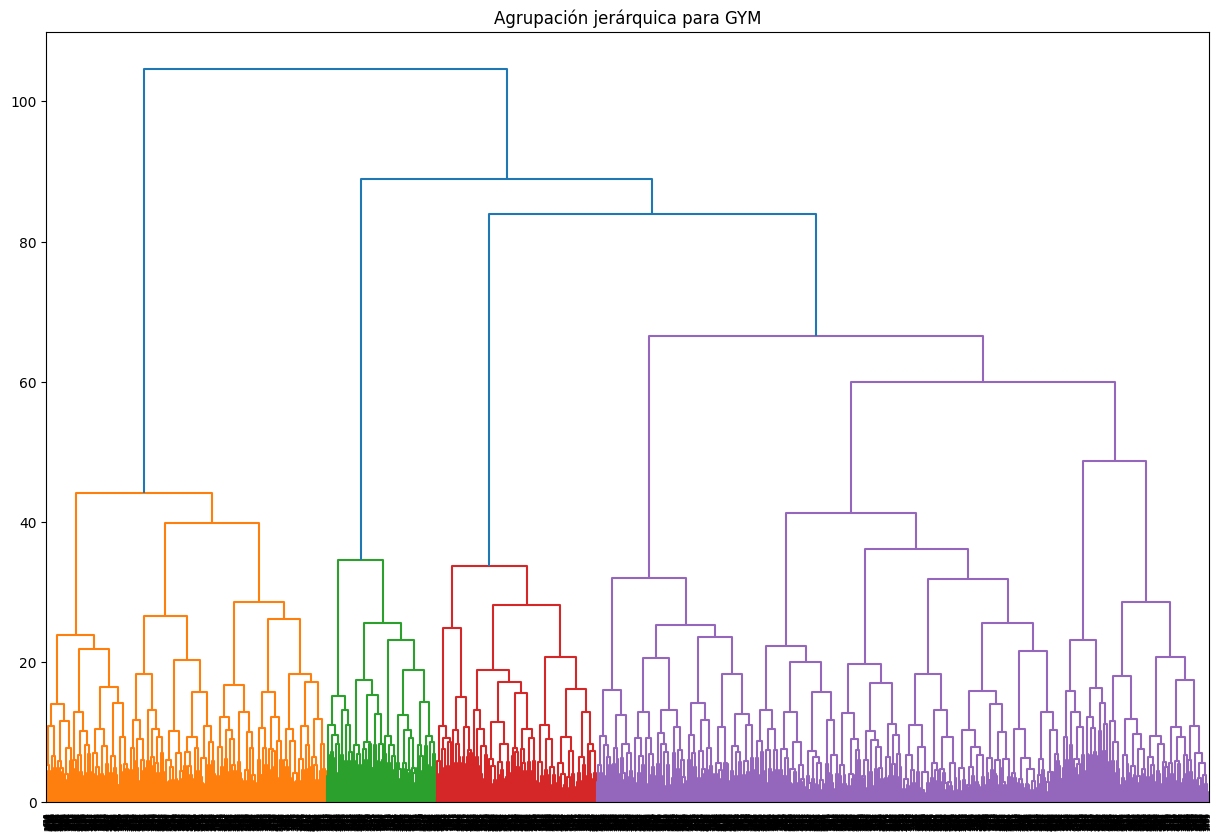

In [8]:
# Dajando de lado la columna Churn
gym_filtrado = gym.drop(columns=['Churn'])

# la estandarización de datos obligatoria antes de pasarlo al algoritmo
sc = StandardScaler()
x_sc = sc.fit_transform(gym_filtrado)

linked = linkage(x_sc, method = 'ward')

# Graficamos el dendograma
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para GYM')
plt.show()


### Conclusiones:
El dendrograma sugiere la existencia de aproximadamente 4 grupos principales de clientes. Sin embargo, para facilitar la comparación de resultados, se entrenó el modelo K-Means con 5 clústeres, tal como se indica en las instrucciones del proyecto.

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Atención</b> ⚠️ - Mencionas que usarás 5 clústeres "para comparar con otros estudiantes". Propuesta: aplicar el método del codo (elbow method) o índice de silueta para justificar 5 clusters con criterios estadísticos. Aunque el dendrograma sugiere 4-5, una métrica cuantitativa fortalecería tu decisión.

</div>

### 4.2 Entrenar el modelo de clustering con el algortimo K-means y predecir los clústeres de clientes.

In [9]:

km = KMeans(n_clusters = 5, random_state=0) # establecer el número de clústeres en 5
labels = km.fit_predict(x_sc) # aplicar el algoritmo a los datos y formar un vector de clúster

#Almacena etiquetas de clúster en el campo de nuestro conjunto de datos
gym['cluster_km'] = labels

# obtiene las estadísticas de los valores medios de las características por clúster
cluster_stats = gym.groupby('cluster_km').mean()
print(gym.groupby('cluster_km').mean().round(2))


            gender  Near_Location  Partner  Promo_friends  Phone  \
cluster_km                                                         
0             0.50           0.96     0.78           0.57    1.0   
1             0.52           0.86     0.47           0.31    0.0   
2             0.50           0.00     0.46           0.08    1.0   
3             0.49           1.00     0.35           0.24    1.0   
4             0.56           0.98     0.36           0.23    1.0   

            Contract_period  Group_visits    Age  \
cluster_km                                         
0                     10.89          0.54  29.98   
1                      4.79          0.43  29.30   
2                      2.35          0.22  28.48   
3                      1.95          0.34  28.17   
4                      2.67          0.47  30.13   

            Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
cluster_km                                                                  
0   

### Conclusiones del análisis de clústeres

El dendrograma sugirió la existencia de aproximadamente 4 grupos principales de clientes. Sin embargo, siguiendo las instrucciones del proyecto, se aplicó el algoritmo K-Means con 5 clústeres para facilitar la comparación de resultados.

El análisis de los valores promedio de cada clúster muestra diferencias claras en el comportamiento de los clientes:

- **Clúster 0** presenta la menor tasa de cancelación (Churn = 0.03). Este grupo se caracteriza por tener los contratos más largos (10.89 meses), el mayor tiempo restante de contrato (9.95 meses), una alta participación en programas de socios y recomendaciones, así como un gasto adicional elevado. Estos clientes representan el segmento más estable y comprometido.

- **Clúster 4** también muestra una tasa de cancelación muy baja (Churn = 0.07). Destaca por presentar la mayor frecuencia de asistencia al gimnasio y una elevada antigüedad promedio, lo que indica un alto nivel de compromiso con el servicio.

- **Clúster 1** presenta una tasa de cancelación intermedia (Churn = 0.27). Sus características muestran valores moderados en la mayoría de las variables analizadas, situándose entre los grupos de alto y bajo riesgo.

- **Clústeres 2 y 3** presentan las tasas de cancelación más elevadas (0.44 y 0.51 respectivamente). Estos grupos tienen contratos más cortos, menor antigüedad y una frecuencia de asistencia significativamente menor, especialmente durante el último mes.

### Hallazgos principales

Los resultados sugieren que los factores más relacionados con la permanencia de los clientes son:

- Una mayor duración del contrato.
- Un mayor tiempo restante de contrato.
- Una mayor antigüedad como miembro del gimnasio.
- Una mayor frecuencia de asistencia.
- Una mayor participación en programas de socios y recomendaciones.
- Un mayor gasto en servicios adicionales.

Por el contrario, los clientes con contratos cortos, baja frecuencia de asistencia y menor antigüedad presentan una probabilidad considerablemente mayor de cancelar su membresía.

En general, la segmentación permitió identificar grupos de clientes con distintos niveles de riesgo de abandono, lo que puede ayudar al gimnasio a diseñar estrategias de retención específicas para cada segmento.

### Tasa de cancelación por clúster

La tasa de cancelación difiere significativamente entre los clústeres, lo que indica que existen grupos de clientes con comportamientos muy distintos respecto al abandono del gimnasio.

**Dado que la variable `Churn` es binaria (0 = permanece, 1 = cancela), el valor promedio de esta variable dentro de cada clúster representa directamente la proporción de clientes que cancelaron su membresía.**

- El **clúster 3** presenta la mayor tasa de cancelación (51%), por lo que representa el grupo con mayor riesgo de abandono.
- El **clúster 2** también muestra una tasa de cancelación elevada (44%), por lo que sus integrantes son igualmente propensos a cancelar su membresía.
- El **clúster 1** presenta una tasa de cancelación intermedia (27%).
- Los **clústeres 0 y 4** son los más leales, con tasas de cancelación de apenas 3% y 7%, respectivamente.

En general, se observa una diferencia considerable entre los grupos más leales y los más propensos al abandono, ya que la tasa de cancelación varía desde un 3% hasta un 51% según el clúster analizado.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - La interpretación de los clústeres es clara y accionable. Identificas correctamente que clústeres 0 y 4 son de bajo riesgo (2.8% y 6.8% churn) mientras que 2 y 3 son alto riesgo (44.4% y 51.4%). Esto te permite seccionar la estrategia de retención por grupo.

</div>

## Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes

### Conclusiones y recomendaciones para la retención de clientes

El análisis permitió identificar distintos segmentos de clientes con comportamientos claramente diferenciados respecto a la cancelación. Los clústeres 0 y 4 presentan las menores tasas de abandono (3% y 7%), mientras que los clústeres 2 y 3 muestran los mayores niveles de riesgo (44% y 51%).

Con base en estos resultados, se proponen las siguientes recomendaciones:

1. **Desarrollar estrategias de retención temprana para los clústeres 2 y 3**

   Estos grupos presentan las tasas de cancelación más elevadas y se caracterizan por contratos cortos, menor antigüedad y baja frecuencia de asistencia. Se recomienda implementar programas de bienvenida, seguimiento personalizado y promociones durante los primeros meses de membresía para aumentar su compromiso con el gimnasio.

2. **Incentivar una mayor frecuencia de asistencia**

   Los clientes de los clústeres con mayor riesgo de abandono registran una menor participación en las actividades del gimnasio. Se pueden implementar recordatorios, retos de asistencia, recompensas por constancia y campañas de comunicación para fomentar hábitos de uso más frecuentes.

3. **Promover contratos de larga duración**

   El clúster 0, que presenta la menor tasa de cancelación, se caracteriza por tener contratos significativamente más largos. Por ello, se recomienda ofrecer descuentos, beneficios exclusivos o facilidades de pago para incentivar la contratación de planes semestrales o anuales.

4. **Potenciar los programas de socios y referidos**

   Los clientes de los clústeres más leales presentan una mayor participación en programas de socios y recomendaciones. El gimnasio podría ampliar estos programas mediante incentivos por referir nuevos clientes y el fortalecimiento de convenios corporativos.

En general, la estrategia de retención debe enfocarse principalmente en los clientes de los clústeres 2 y 3, ya que concentran el mayor riesgo de abandono, mientras que las características de los clústeres 0 y 4 pueden utilizarse como referencia para diseñar programas que fomenten la fidelización de los demás segmentos.


<div class="alert alert-block alert-success">
<b>Comentario del Revisor (iteración 1)</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - Tus recomendaciones son específicas y vinculadas directamente a los hallazgos del análisis. Propuestas como incentivar contratos de largo plazo, seguimiento a baja frecuencia y estrategias para clientes nuevos demuestran integración del insights analítico en estrategia empresarial.

</div>